# پروژه پیش‌بینی شاخص بورس ایران
## Notebook 04 — مدل هیبرید ۳ لایه: PCA → RF → GRU

این مدل **showcase** پروژه است و به‌صراحت در نظرات استاد راهنما خواسته شده است.

| لایه | روش | نقش |
|------|-----|-----|
| **لایه ۱** | PCA | کاهش ابعاد + حذف multicollinearity |
| **لایه ۲** | Random Forest | استخراج اهمیت PC ها + انتخاب ویژگی |
| **لایه ۳** | GRU | پیش‌بینی نهایی با دینامیک زمانی |

| موضوع | جزئیات |
|-------|---------|
| ورودی PCA | ۱۹ ویژگی کلان‌اقتصادی + lag |
| PC های انتخابی | بر اساس RF importance |
| هدف GRU | `log_stock_price` |
| نمودارها | ۱۴ نمودار از ۱۰ نوع |

> **پیش‌نیاز:** اجرای notebooks 00، 01، 02، 03

## ۱. بارگذاری کتابخانه‌ها

In [42]:
import os, sys, warnings, random
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import arabic_reshaper
from bidi.algorithm import get_display
sys.path.append("..")
from src.utils import load_data, get_train_test

def fp(text):
    return get_display(arabic_reshaper.reshape(str(text)))

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

plt.rcParams["figure.dpi"]  = 120
plt.rcParams["grid.alpha"]  = 0.3
plt.rcParams["font.family"] = "DejaVu Sans"
os.makedirs("../results/figures", exist_ok=True)
print(f"✓ PyTorch: {torch.__version__} | Device: {DEVICE}")

✓ PyTorch: 2.12.0+cpu | Device: cpu


## ۲. بارگذاری داده و مهندسی ویژگی

In [43]:
df = load_data()
train, test = get_train_test(df, test_quarters=16)

# ── ویژگی‌های پایه برای PCA
MACRO_COLS = [
    "oil","gold","export","import","exchange","liquidity","cpi","cycle",
    "oil_x_cycle","gold_x_cycle","export_x_cycle","import_x_cycle",
    "exchange_x_cycle","liquidity_x_cycle","cpi_x_cycle"
]

# ── اضافه کردن lag های log_return
for lag in [1, 2, 3, 4]:
    df[f"lr_lag{lag}"] = df["log_return"].shift(lag)
df["lr_roll_mean4"] = df["log_return"].rolling(4).mean()
df["lr_roll_std4"]  = df["log_return"].rolling(4).std()
df["oil_yoy"]       = df["oil"].pct_change(4)
df["exchange_yoy"]  = df["exchange"].pct_change(4)

ALL_FEAT_COLS = MACRO_COLS + [
    "lr_lag1","lr_lag2","lr_lag3","lr_lag4",
    "lr_roll_mean4","lr_roll_std4","oil_yoy","exchange_yoy"
]

df_c   = df.dropna(subset=ALL_FEAT_COLS + ["log_stock_price","log_return"]).copy()
train_c = df_c.loc[df_c.index.isin(train.index)]
test_c  = df_c.loc[df_c.index.isin(test.index)]

y_true_price = test_c["stock_price"].values
y_true_log   = test_c["log_stock_price"].values
N_TRAIN      = len(train_c)
N_TEST       = len(test_c)

print(f"✓ آموزش: {N_TRAIN} | آزمون: {N_TEST}")
print(f"✓ ویژگی‌های ورودی PCA: {len(ALL_FEAT_COLS)}")

✓ آموزش: 71 | آزمون: 16
✓ ویژگی‌های ورودی PCA: 23


## ۳. نمودار معماری هیبرید

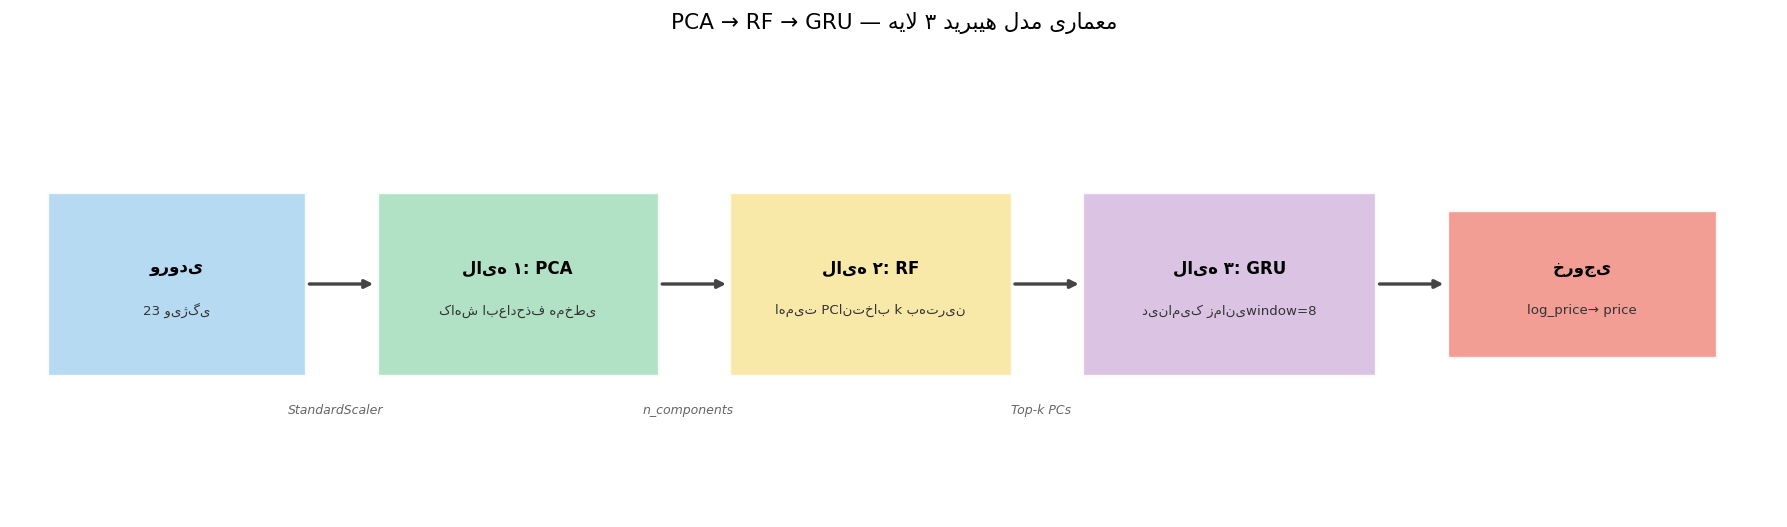

✓ نمودار ۱ ذخیره شد


In [44]:
# نمودار ۱ — معماری pipeline
fig, ax = plt.subplots(figsize=(15, 4.5))
ax.axis("off"); ax.set_xlim(0,15); ax.set_ylim(0,5)

def box(x,y,w,h,title,sub,col):
    ax.add_patch(plt.Rectangle((x,y),w,h,fc=col,ec="white",lw=2,zorder=3,alpha=0.9))
    ax.text(x+w/2,y+h/2+0.18,title,ha="center",va="center",
            fontsize=10,fontweight="bold",zorder=4)
    ax.text(x+w/2,y+h/2-0.28,sub,ha="center",va="center",
            fontsize=8,color="#333",zorder=4)

def arr(x1,x2,y_):
    ax.annotate("",xy=(x2,y_),xytext=(x1,y_),
                arrowprops=dict(arrowstyle="-|>",color="#444",lw=2.0))

# بلوک‌ها
box(0.3, 1.5, 2.2, 2,   "ورودی",          f"{len(ALL_FEAT_COLS)} ویژگی", "#aed6f1")
arr(2.5, 3.1, 2.5)
box(3.1, 1.5, 2.4, 2,   "لایه ۱: PCA",    "کاهش ابعادحذف همخطی", "#a9dfbf")
arr(5.5, 6.1, 2.5)
box(6.1, 1.5, 2.4, 2,   "لایه ۲: RF",     "اهمیت PCانتخاب k بهترین", "#f9e79f")
arr(8.5, 9.1, 2.5)
box(9.1, 1.5, 2.5, 2,   "لایه ۳: GRU",    "دینامیک زمانیwindow=8", "#d7bde2")
arr(11.6,12.2,2.5)
box(12.2,1.7, 2.3, 1.6, "خروجی", "log_price→ price", "#f1948a")

# برچسب‌های زیر فلش
for x_, lbl in [(2.75,"StandardScaler"), (5.75,"n_components"), (8.75,"Top-k PCs")]:
    ax.text(x_,1.1,lbl,ha="center",fontsize=7.5,color="#666",style="italic")

ax.set_title(fp("معماری مدل هیبرید ۳ لایه — PCA → RF → GRU"), fontsize=13, pad=15)
plt.tight_layout()
plt.savefig("../results/figures/04_hybrid_architecture.png",dpi=150,bbox_inches="tight")
plt.show()
print("✓ نمودار ۱ ذخیره شد")

## ۴. لایه ۱ — PCA: کاهش ابعاد

### چرا PCA؟
متغیرهای کلان اقتصادی ایران (نقدینگی، تورم، نرخ ارز) همگی با تورم همبسته‌اند.
VIF بالا در notebook 02 نشان داد که multicollinearity شدید وجود دارد.
PCA این همبستگی را مدیریت کرده و اطلاعات را در PC های مستقل فشرده می‌کند.

In [45]:
# ── نرمال‌سازی (StandardScaler — ضروری قبل از PCA)
std_scaler = StandardScaler()
X_tr_sc    = std_scaler.fit_transform(train_c[ALL_FEAT_COLS].values)
X_te_sc    = std_scaler.transform(test_c[ALL_FEAT_COLS].values)

# ── PCA روی کل ویژگی‌ها
pca_full = PCA(n_components=len(ALL_FEAT_COLS), random_state=SEED)
pca_full.fit(X_tr_sc)

cum_var = np.cumsum(pca_full.explained_variance_ratio_)
n_95    = int(np.searchsorted(cum_var, 0.95)) + 1
n_99    = int(np.searchsorted(cum_var, 0.99)) + 1

print(f"✓ برای پوشش 95% واریانس: {n_95} PC کافی است")
print(f"✓ برای پوشش 99% واریانس: {n_99} PC کافی است")
print(f"\nواریانس تجمعی اولین ۱۰ PC:")
for i, v in enumerate(cum_var[:10], 1):
    bar = "█" * int(v*20)
    print(f"  PC{i:2d}: {v:.3f}  {bar}")

✓ برای پوشش 95% واریانس: 9 PC کافی است
✓ برای پوشش 99% واریانس: 12 PC کافی است

واریانس تجمعی اولین ۱۰ PC:
  PC 1: 0.462  █████████
  PC 2: 0.604  ████████████
  PC 3: 0.687  █████████████
  PC 4: 0.752  ███████████████
  PC 5: 0.814  ████████████████
  PC 6: 0.869  █████████████████
  PC 7: 0.907  ██████████████████
  PC 8: 0.939  ██████████████████
  PC 9: 0.959  ███████████████████
  PC10: 0.976  ███████████████████


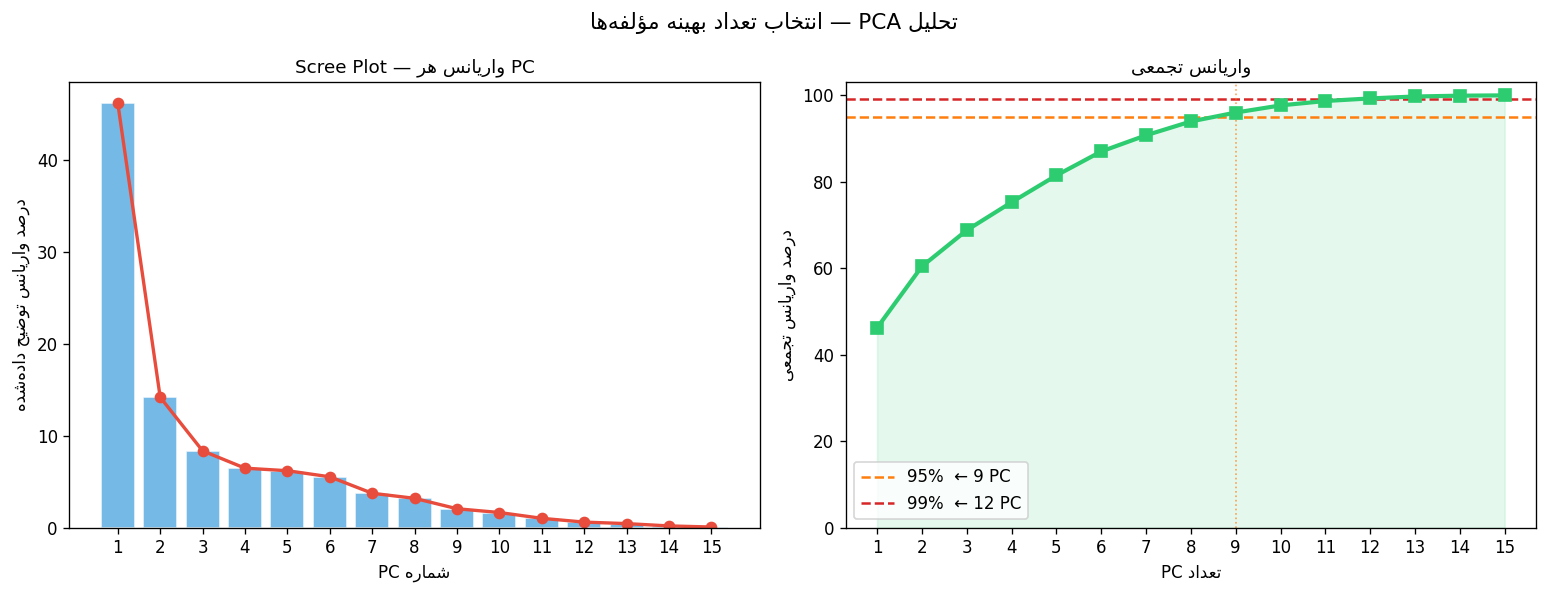

✓ نمودار ۲ ذخیره شد


In [46]:
# نمودار ۲ — Scree Plot + واریانس تجمعی
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# scree plot
n_show = 15
axes[0].bar(range(1,n_show+1), pca_full.explained_variance_ratio_[:n_show]*100,
            color="#5dade2", alpha=0.85, edgecolor="white")
axes[0].plot(range(1,n_show+1), pca_full.explained_variance_ratio_[:n_show]*100,
             "o-", color="#e74c3c", lw=2, ms=6)
axes[0].set_title(fp("Scree Plot — واریانس هر PC"), fontsize=11)
axes[0].set_xlabel(fp("شماره PC"))
axes[0].set_ylabel(fp("درصد واریانس توضیح داده‌شده"))
axes[0].set_xticks(range(1,n_show+1))

# واریانس تجمعی
axes[1].plot(range(1,n_show+1), cum_var[:n_show]*100,
             "s-", color="#2ecc71", lw=2.5, ms=7, zorder=3)
axes[1].axhline(95, color="#ff7f0e", lw=1.5, linestyle="--",
                label=fp(f"95%  ← {n_95} PC"))
axes[1].axhline(99, color="#d62728", lw=1.5, linestyle="--",
                label=fp(f"99%  ← {n_99} PC"))
axes[1].axvline(n_95, color="#ff7f0e", lw=1, linestyle=":", alpha=0.7)
axes[1].fill_between(range(1,n_show+1), 0, cum_var[:n_show]*100,
                      alpha=0.12, color="#2ecc71")
axes[1].set_title(fp("واریانس تجمعی"), fontsize=11)
axes[1].set_xlabel(fp("تعداد PC"))
axes[1].set_ylabel(fp("درصد واریانس تجمعی"))
axes[1].set_xticks(range(1,n_show+1))
axes[1].legend(); axes[1].set_ylim(0,103)

plt.suptitle(fp("تحلیل PCA — انتخاب تعداد بهینه مؤلفه‌ها"), fontsize=13)
plt.tight_layout()
plt.savefig("../results/figures/04_pca_scree.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ نمودار ۲ ذخیره شد")

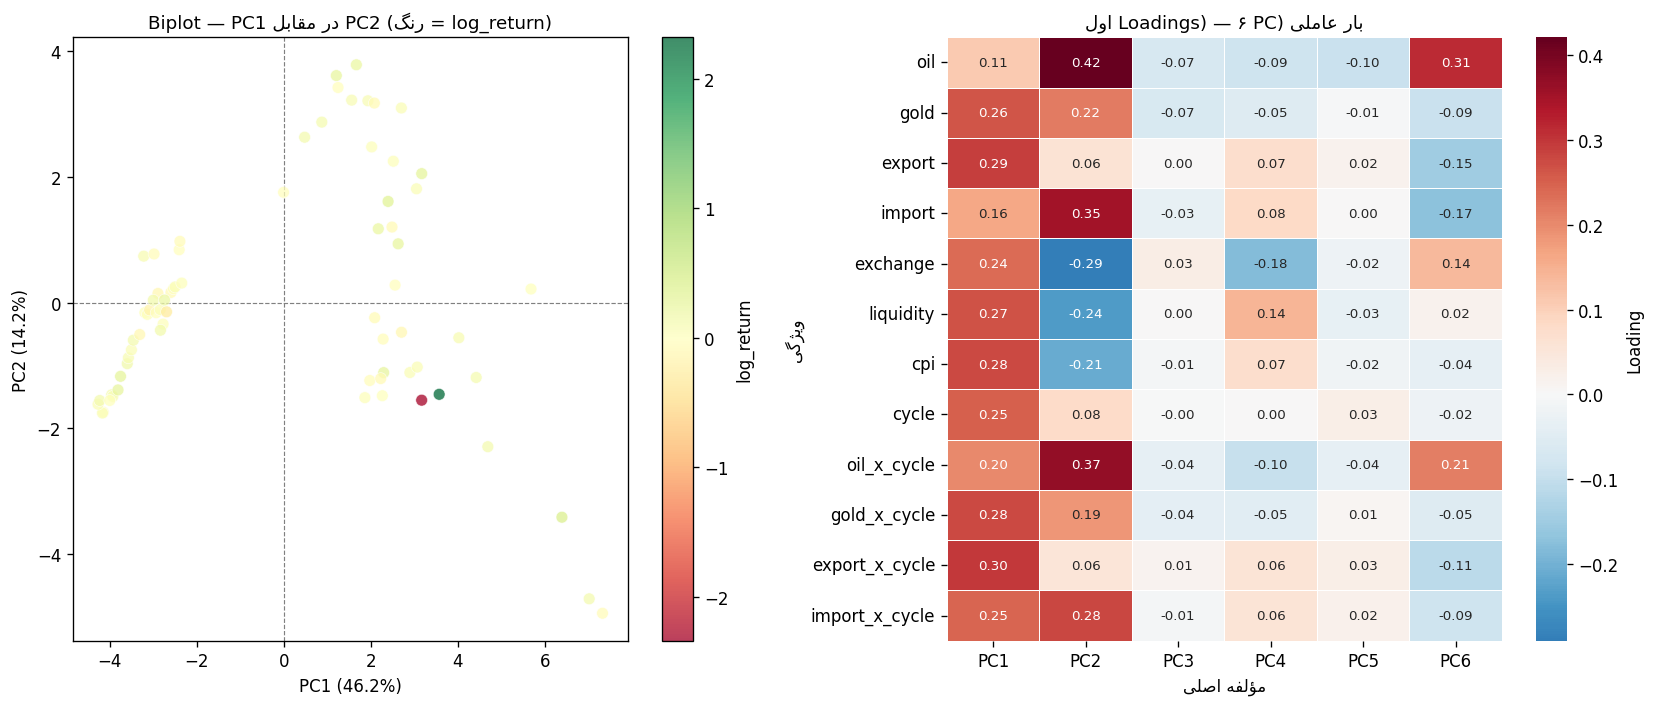

✓ نمودار ۳ ذخیره شد | X_tr_pca: (71, 12) | X_te_pca: (16, 12)


In [47]:
# نمودار ۳ — Biplot (PC1 vs PC2) + بار عاملی
pca_n99 = PCA(n_components=n_99, random_state=SEED)
X_tr_pca = pca_n99.fit_transform(X_tr_sc)
X_te_pca = pca_n99.transform(X_te_sc)

loadings = pca_n99.components_[:2].T   # (n_features, 2)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Biplot: نقاط train رنگ‌بندی بر اساس log_return
sc_vals = train_c["log_return"].values
scatter = axes[0].scatter(X_tr_pca[:,0], X_tr_pca[:,1],
                          c=sc_vals, cmap="RdYlGn", s=50, alpha=0.75,
                          edgecolors="white", lw=0.4, zorder=3)
plt.colorbar(scatter, ax=axes[0], label=fp("log_return"))
axes[0].axhline(0, color="gray", lw=0.7, linestyle="--")
axes[0].axvline(0, color="gray", lw=0.7, linestyle="--")
axes[0].set_xlabel(fp(f"PC1 ({pca_n99.explained_variance_ratio_[0]*100:.1f}%)"))
axes[0].set_ylabel(fp(f"PC2 ({pca_n99.explained_variance_ratio_[1]*100:.1f}%)"))
axes[0].set_title(fp("Biplot — PC1 در مقابل PC2 (رنگ = log_return)"), fontsize=11)

# ── Heatmap بار عاملی (loadings)
n_show_feat = min(len(ALL_FEAT_COLS), 12)
load_df = pd.DataFrame(
    pca_n99.components_[:6, :n_show_feat].T,
    index=ALL_FEAT_COLS[:n_show_feat],
    columns=[f"PC{i+1}" for i in range(6)]
)
sns.heatmap(load_df, cmap="RdBu_r", center=0, annot=True, fmt=".2f",
            linewidths=0.4, ax=axes[1], annot_kws={"size":8},
            cbar_kws={"label":"Loading"})
axes[1].set_title(fp("بار عاملی (Loadings) — ۶ PC اول"), fontsize=11)
axes[1].set_xlabel(fp("مؤلفه اصلی"))
axes[1].set_ylabel(fp("ویژگی"))

plt.tight_layout()
plt.savefig("../results/figures/04_pca_biplot_loadings.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ نمودار ۳ ذخیره شد | X_tr_pca: {X_tr_pca.shape} | X_te_pca: {X_te_pca.shape}")

## ۵. لایه ۲ — Random Forest: استخراج اهمیت PC ها

### چرا RF بعد از PCA؟
PCA همه PC ها را برابر تولید می‌کند — نمی‌داند کدام برای پیش‌بینی مهم‌تر است.
RF روی PC ها آموزش می‌بیند و **اهمیت هر PC** را نسبت به هدف مشخص می‌کند.
سپس فقط **top-k PC** با بیشترین اهمیت به GRU داده می‌شود.

In [48]:
# آموزش RF روی PC های حاصل از PCA
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=4,
    min_samples_leaf=3,
    max_features="sqrt",
    random_state=SEED,
    n_jobs=-1
)
rf_model.fit(X_tr_pca, train_c["log_return"].values)

importances = rf_model.feature_importances_
pc_names    = [f"PC{i+1}" for i in range(n_99)]
imp_df      = pd.DataFrame({"PC": pc_names, "importance": importances})              .sort_values("importance", ascending=False)

print("اهمیت PC ها (RF):")
for _, row in imp_df.iterrows():
    bar = "█" * int(row["importance"]*200)
    print(f"  {row['PC']:5s}: {row['importance']:.4f}  {bar}")

اهمیت PC ها (RF):
  PC10 : 0.1436  ████████████████████████████
  PC12 : 0.1414  ████████████████████████████
  PC3  : 0.1087  █████████████████████
  PC5  : 0.1080  █████████████████████
  PC4  : 0.1010  ████████████████████
  PC8  : 0.0843  ████████████████
  PC7  : 0.0733  ██████████████
  PC11 : 0.0685  █████████████
  PC9  : 0.0545  ██████████
  PC6  : 0.0535  ██████████
  PC1  : 0.0437  ████████
  PC2  : 0.0195  ███


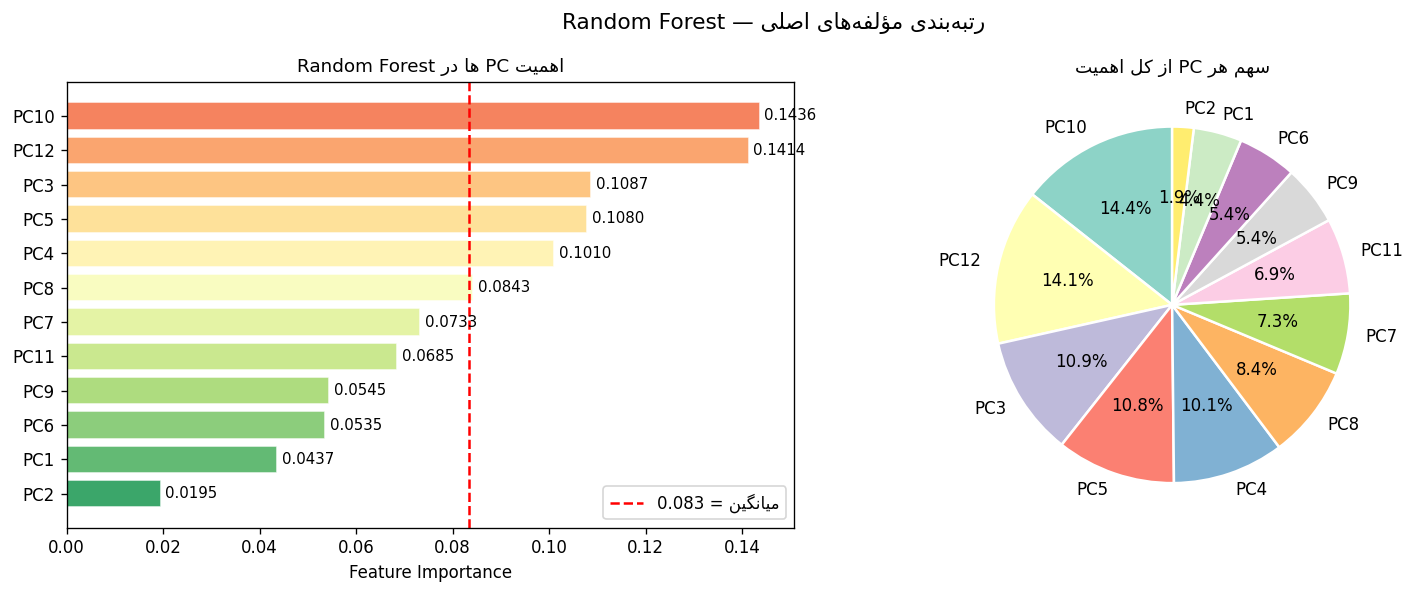

✓ نمودار ۴ ذخیره شد


In [49]:
# نمودار ۴ — RF Feature Importance روی PC ها
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── bar chart اهمیت
colors_imp = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(imp_df)))[::-1]
bars = axes[0].barh(imp_df["PC"][::-1], imp_df["importance"][::-1],
                     color=colors_imp, alpha=0.85, edgecolor="white")
for bar, val in zip(bars, imp_df["importance"][::-1]):
    axes[0].text(val+0.001, bar.get_y()+bar.get_height()/2,
                 f"{val:.4f}", va="center", fontsize=9)
axes[0].set_title(fp("اهمیت PC ها در Random Forest"), fontsize=11)
axes[0].set_xlabel(fp("Feature Importance"))
axes[0].axvline(1/n_99, color="red", lw=1.5, linestyle="--",
                label=fp(f"میانگین = {1/n_99:.3f}"))
axes[0].legend()

# ── pie chart تجمعی
top_k_vals = imp_df["importance"].values
axes[1].pie(top_k_vals,
            labels=imp_df["PC"].values,
            autopct="%1.1f%%",
            colors=plt.cm.Set3(np.linspace(0,1,len(top_k_vals))),
            startangle=90,
            wedgeprops=dict(edgecolor="white", linewidth=1.5))
axes[1].set_title(fp("سهم هر PC از کل اهمیت"), fontsize=11)

plt.suptitle(fp("Random Forest — رتبه‌بندی مؤلفه‌های اصلی"), fontsize=13)
plt.tight_layout()
plt.savefig("../results/figures/04_rf_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ نمودار ۴ ذخیره شد")

In [50]:
# ── انتخاب top-k PC بر اساس RF importance
# معیار: PC هایی که importance > میانگین دارند
mean_imp = importances.mean()
top_k_mask  = importances > mean_imp
K_SELECTED  = int(top_k_mask.sum())
K_SELECTED  = max(K_SELECTED, 4)   # حداقل ۴ PC

# مرتب‌سازی بر اساس اهمیت و انتخاب top K
top_k_idx   = np.argsort(importances)[::-1][:K_SELECTED]
top_k_idx   = np.sort(top_k_idx)   # مرتب بر اساس شماره PC

X_tr_selected = X_tr_pca[:, top_k_idx]   # (n_train, K)
X_te_selected = X_te_pca[:, top_k_idx]   # (n_test, K)

print(f"✓ PC های انتخابی (K={K_SELECTED}): {[pc_names[i] for i in top_k_idx]}")
print(f"✓ واریانس این PC ها: {pca_n99.explained_variance_ratio_[top_k_idx].sum()*100:.1f}%")

# اضافه کردن log_stock_price scale‌شده به عنوان input اضافه
price_sc = MinMaxScaler()
y_tr_log_sc = price_sc.fit_transform(
    train_c["log_stock_price"].values.reshape(-1,1)).flatten()
y_te_log_sc = price_sc.transform(
    test_c["log_stock_price"].values.reshape(-1,1)).flatten()
y_all_log_sc = np.concatenate([y_tr_log_sc, y_te_log_sc])

✓ PC های انتخابی (K=6): ['PC3', 'PC4', 'PC5', 'PC8', 'PC10', 'PC12']
✓ واریانس این PC ها: 26.5%


## ۶. لایه ۳ — GRU: پیش‌بینی نهایی

### ورودی GRU
برخلاف notebook 03 که فقط قیمت رو می‌دید، اینجا GRU:
- **log_stock_price** (scaled)
- **top-k PC** از لایه قبل

را با هم در پنجره‌های زمانی می‌بیند → اطلاعات غنی‌تر.

In [51]:
WINDOW      = 8
INPUT_SIZE  = 1 + K_SELECTED   # قیمت + PC های انتخابی

# ── ساخت feature matrix کامل: [log_price_scaled, PC_1, PC_2, ...]
# برای train
X_combined_tr = np.hstack([
    y_tr_log_sc.reshape(-1,1),
    X_tr_selected
])  # (N_TRAIN, 1+K)

# برای test (با کشویی‌کردن از آخر train)
X_combined_all = np.vstack([
    np.hstack([y_tr_log_sc.reshape(-1,1), X_tr_selected]),
    np.hstack([y_te_log_sc.reshape(-1,1), X_te_selected])
])  # (N_TRAIN+N_TEST, 1+K)

# ── ساخت دنباله‌ها
def make_seqs(X_all, y_all_sc, n_tr, window, n_te):
    X_tr_seq, y_tr_seq = [], []
    for i in range(n_tr - window):
        X_tr_seq.append(X_all[i:i+window])
        y_tr_seq.append(y_all_sc[i+window])
    X_te_seq, y_te_seq = [], []
    for t in range(n_te):
        start = n_tr - window + t
        X_te_seq.append(X_all[start:start+window])
        y_te_seq.append(y_all_sc[n_tr+t])
    return (np.array(X_tr_seq, dtype=np.float32),
            np.array(y_tr_seq, dtype=np.float32),
            np.array(X_te_seq, dtype=np.float32),
            np.array(y_te_seq, dtype=np.float32))

Xtr_seq, ytr_seq, Xte_seq, yte_seq = make_seqs(
    X_combined_all, y_all_log_sc, N_TRAIN, WINDOW, N_TEST)

print(f"✓ دنباله آموزش: {Xtr_seq.shape}  (samples × window × features)")
print(f"✓ دنباله آزمون: {Xte_seq.shape}")

✓ دنباله آموزش: (63, 8, 7)  (samples × window × features)
✓ دنباله آزمون: (16, 8, 7)


In [52]:
# ── معماری GRU چندمتغیره
class HybridGRU(nn.Module):
    def __init__(self, input_size, hidden_size=32, num_layers=2, dropout=0.2):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers,
                          batch_first=True,
                          dropout=dropout if num_layers>1 else 0.0)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, hidden_size//2),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_size//2, 1)
        )
    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(self.dropout(out[:,-1,:])).squeeze(-1)

# ── Dataset
class TSDataset(torch.utils.data.Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X).to(DEVICE)
        self.y = torch.FloatTensor(y).to(DEVICE)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

# تقسیم validation
N_VAL = 12
tr_loader = DataLoader(TSDataset(Xtr_seq[:-N_VAL], ytr_seq[:-N_VAL]),
                        batch_size=16, shuffle=False)
vl_X, vl_y = Xtr_seq[-N_VAL:], ytr_seq[-N_VAL:]

model = HybridGRU(input_size=INPUT_SIZE, hidden_size=32).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())
print(f"✓ معماری: input={INPUT_SIZE} | hidden=32 | layers=2")
print(f"✓ تعداد پارامتر: {total_params:,}")

✓ معماری: input=7 | hidden=32 | layers=2
✓ تعداد پارامتر: 10,817


In [53]:
# ── آموزش با EarlyStopping
MAX_EPOCHS = 400; PATIENCE = 40; LR_PAT = 15
optimizer  = torch.optim.Adam(model.parameters(), lr=0.008, weight_decay=1e-4)
scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(
                optimizer, mode="min", factor=0.5, patience=LR_PAT)
criterion  = nn.MSELoss()

history    = {"train":[], "val":[], "lr":[]}
best_val   = np.inf; best_wts = None; no_imp = 0

for epoch in range(1, MAX_EPOCHS+1):
    model.train()
    ep_loss = 0
    for Xb, yb in tr_loader:
        optimizer.zero_grad()
        loss = criterion(model(Xb), yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        ep_loss += loss.item()
    tl = ep_loss / len(tr_loader)
    model.eval()
    with torch.no_grad():
        vl_pred = model(torch.FloatTensor(vl_X).to(DEVICE)).cpu().numpy()
    vl = float(np.sqrt(mean_squared_error(vl_y, vl_pred)))
    scheduler.step(vl)
    history["train"].append(tl)
    history["val"].append(vl)
    history["lr"].append(optimizer.param_groups[0]["lr"])
    if vl < best_val:
        best_val = vl; best_wts = {k:v.clone() for k,v in model.state_dict().items()}; no_imp = 0
    else:
        no_imp += 1
    if epoch % 50 == 0 or epoch == 1:
        print(f"  Epoch {epoch:4d} | train={tl:.5f} | val={vl:.5f}")
    if no_imp >= PATIENCE:
        print(f"\n  ⏹ EarlyStopping در epoch {epoch} (best={best_val:.5f})")
        break

model.load_state_dict(best_wts)
best_epoch = int(np.argmin(history["val"])) + 1
print(f"\n✓ بهترین epoch: {best_epoch}")

  Epoch    1 | train=0.28721 | val=0.56184

  ⏹ EarlyStopping در epoch 42 (best=0.29675)

✓ بهترین epoch: 2


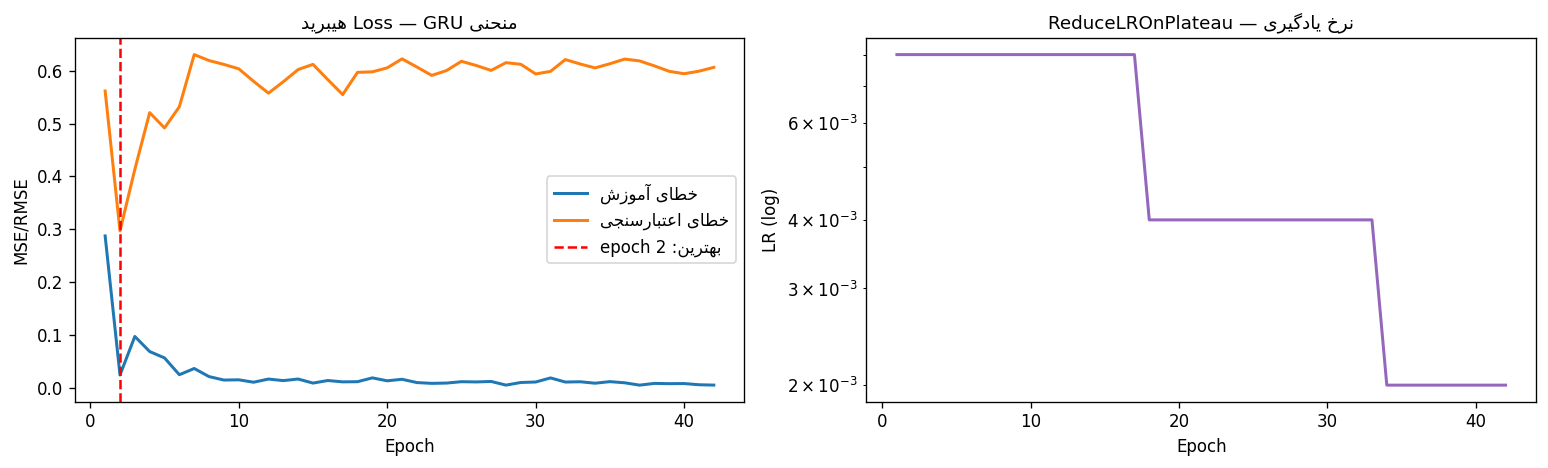

✓ نمودار ۵ ذخیره شد


In [54]:
# نمودار ۵ — منحنی آموزش
epochs_ran = range(1, len(history["train"])+1)
fig, axes  = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(epochs_ran, history["train"], color="#1f77b4", lw=1.8,
             label=fp("خطای آموزش"))
axes[0].plot(epochs_ran, history["val"], color="#ff7f0e", lw=1.8,
             label=fp("خطای اعتبارسنجی"))
axes[0].axvline(best_epoch, color="red", lw=1.5, linestyle="--",
                label=fp(f"بهترین: epoch {best_epoch}"))
axes[0].set_title(fp("منحنی Loss — GRU هیبرید"), fontsize=11)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("MSE/RMSE"); axes[0].legend()

axes[1].semilogy(epochs_ran, history["lr"], color="#9467bd", lw=1.8)
axes[1].set_title(fp("نرخ یادگیری — ReduceLROnPlateau"), fontsize=11)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel(fp("LR (log)"))

plt.tight_layout()
plt.savefig("../results/figures/04_training_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ نمودار ۵ ذخیره شد")

## ۷. پیش‌بینی روی داده آزمون

In [55]:
model.eval()
with torch.no_grad():
    pred_sc = model(torch.FloatTensor(Xte_seq).to(DEVICE)).cpu().numpy()

y_pred_log   = price_sc.inverse_transform(pred_sc.reshape(-1,1)).flatten()
y_pred_price = np.exp(y_pred_log)
x_t          = range(N_TEST)

result_df = pd.DataFrame({
    "دوره":     test_c.index.astype(str),
    "واقعی":    y_true_price.astype(int),
    "پیش‌بینی": y_pred_price.astype(int),
    "خطا (%)":  np.round((y_pred_price-y_true_price)/y_true_price*100, 2),
    "چرخه":     test_c["cycle"].values.astype(int)
})
print(result_df.to_string(index=False))

  دوره   واقعی  پیش‌بینی  خطا (%)  چرخه
2019Q1  234879     56810   -75.81     3
2019Q2  302104     62653   -79.26     1
2019Q3  353997     73533   -79.23     1
2019Q4  512901     72877   -85.79     1
2020Q1 1270627     78002   -93.86     1
2020Q2 1595160     70701   -95.57     1
2020Q3 1439124     66745   -95.36     1
2020Q4 1307707     70714   -94.59     1
2021Q1 1168665     69706   -94.04     1
2021Q2 1386451     72693   -94.76     1
2021Q3 1318360     74781   -94.33     1
2021Q4 1367250     74958   -94.52     1
2022Q1 1539632     76024   -95.06     1
2022Q2 1355241     76030   -94.39     1
2022Q3 1496201     78823   -94.73     1
2022Q4 1960457     77248   -96.06     1


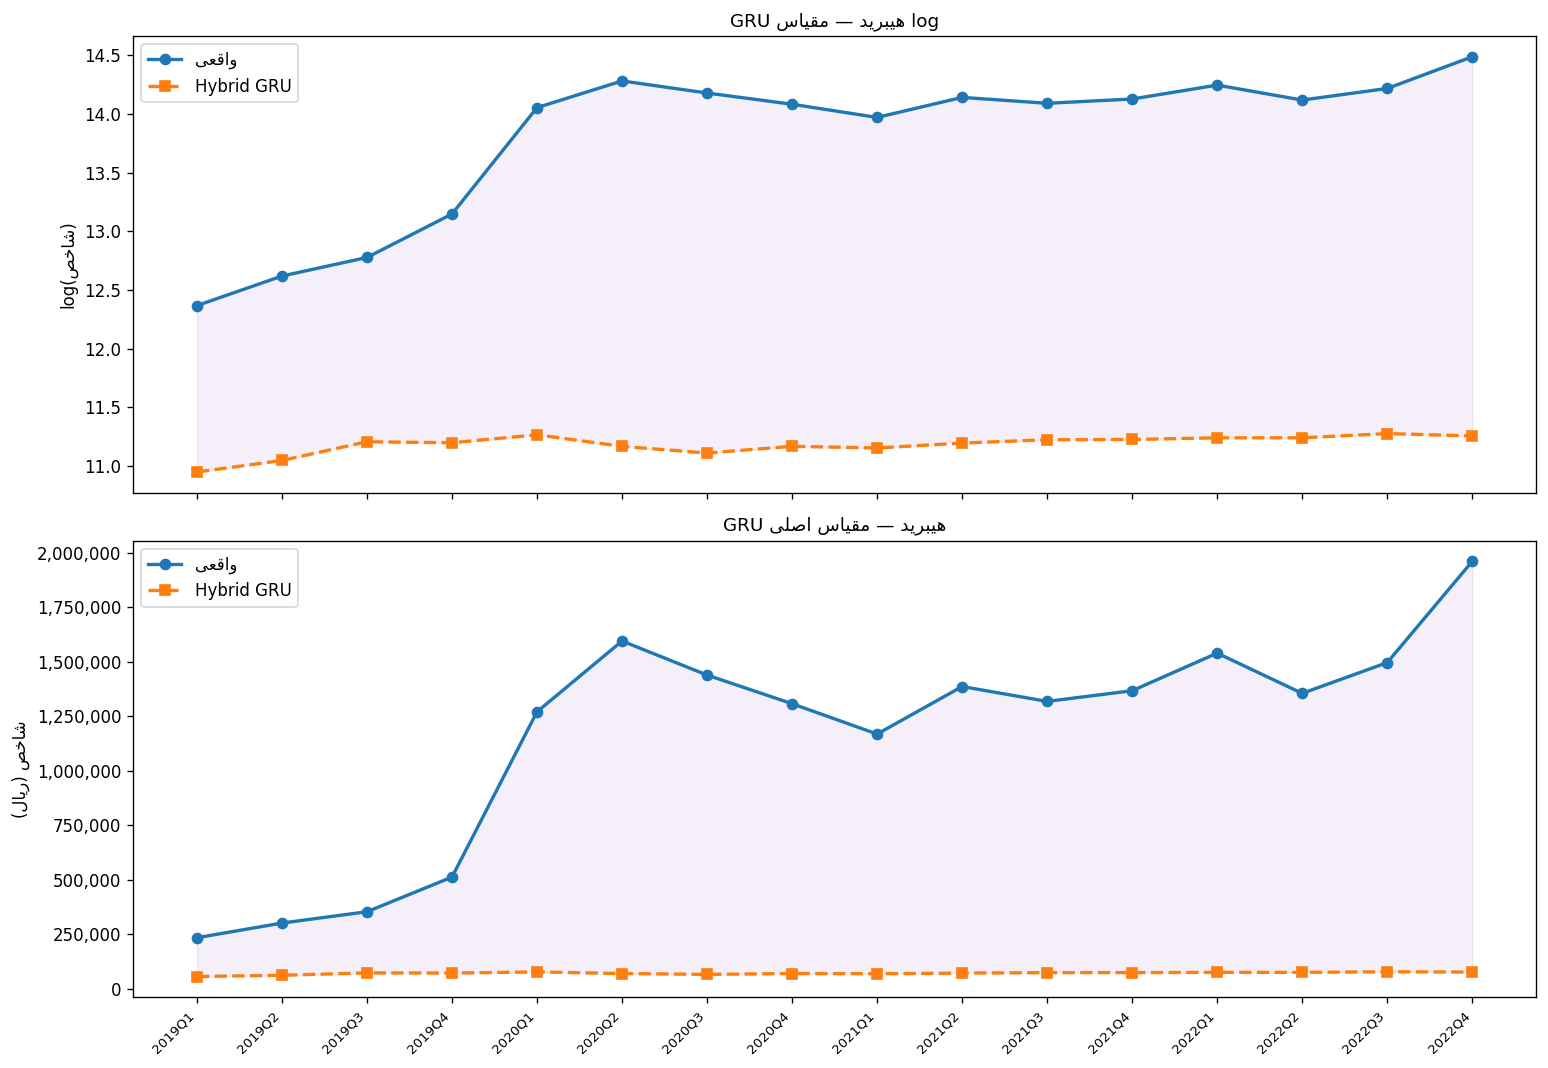

✓ نمودار ۶ ذخیره شد


In [56]:
# نمودار ۶ — Actual vs Predicted (log + price)
fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)
for ax_i, (ytrue, ypred, ylabel, title) in enumerate([
    (y_true_log, y_pred_log,
     fp("log(شاخص)"), fp("GRU هیبرید — مقیاس log")),
    (y_true_price, y_pred_price,
     fp("شاخص (ریال)"), fp("GRU هیبرید — مقیاس اصلی"))
]):
    axes[ax_i].plot(x_t, ytrue, color="#1f77b4", marker="o", ms=6,
                    lw=2, label=fp("واقعی"), zorder=4)
    axes[ax_i].plot(x_t, ypred, color="#ff7f0e", marker="s", ms=6,
                    lw=2, linestyle="--", label=fp("Hybrid GRU"), zorder=4)
    axes[ax_i].fill_between(x_t, ytrue, ypred, alpha=0.1, color="#9467bd")
    axes[ax_i].set_ylabel(ylabel); axes[ax_i].set_title(title, fontsize=11)
    axes[ax_i].legend()
    if ax_i == 1:
        axes[ax_i].yaxis.set_major_formatter(
            mticker.FuncFormatter(lambda x,_: f"{x:,.0f}"))
        axes[ax_i].set_xticks(x_t)
        axes[ax_i].set_xticklabels(test_c.index.astype(str),
                                    rotation=45, ha="right", fontsize=8)
plt.tight_layout()
plt.savefig("../results/figures/04_actual_vs_predicted.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ نمودار ۶ ذخیره شد")

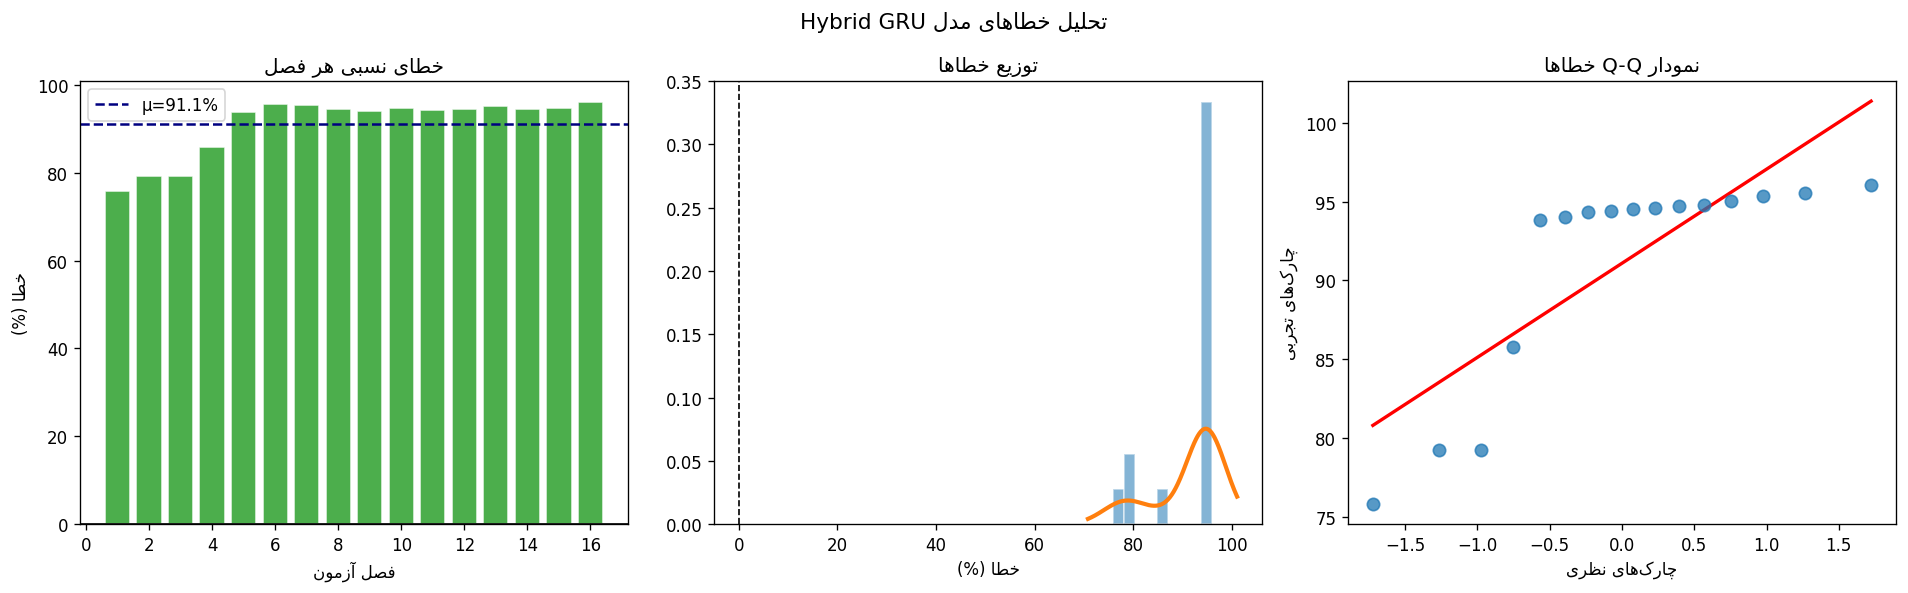

✓ نمودار ۷ ذخیره شد


In [57]:
# نمودار ۷ — تحلیل خطاها (bar + hist/KDE + QQ)
from scipy.stats import gaussian_kde, probplot
res_pct = (y_true_price - y_pred_price) / y_true_price * 100

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

bar_c = ["#2ca02c" if r>0 else "#d62728" for r in res_pct]
axes[0].bar(range(1,17), res_pct, color=bar_c, alpha=0.85, edgecolor="white")
axes[0].axhline(0, color="black", lw=1)
axes[0].axhline(np.mean(res_pct), color="navy", lw=1.5, linestyle="--",
                label=fp(f"μ={np.mean(res_pct):.1f}%"))
axes[0].set_title(fp("خطای نسبی هر فصل")); axes[0].legend()
axes[0].set_xlabel(fp("فصل آزمون")); axes[0].set_ylabel(fp("خطا (%)"))

axes[1].hist(res_pct, bins=9, color="#1f77b4", alpha=0.55, edgecolor="white", density=True)
x_kde = np.linspace(res_pct.min()-5, res_pct.max()+5, 300)
axes[1].plot(x_kde, gaussian_kde(res_pct)(x_kde), color="#ff7f0e", lw=2.5)
axes[1].axvline(0, color="black", lw=1, linestyle="--")
axes[1].set_title(fp("توزیع خطاها")); axes[1].set_xlabel(fp("خطا (%)"))

(osm, osr), (slope, intercept, _) = probplot(res_pct, dist="norm")
axes[2].scatter(osm, osr, color="#1f77b4", alpha=0.75, s=55, zorder=3)
xl = np.array([min(osm), max(osm)])
axes[2].plot(xl, slope*xl+intercept, color="red", lw=2)
axes[2].set_title(fp("نمودار Q-Q خطاها"))
axes[2].set_xlabel(fp("چارک‌های نظری")); axes[2].set_ylabel(fp("چارک‌های تجربی"))

plt.suptitle(fp("تحلیل خطاهای مدل Hybrid GRU"), fontsize=13)
plt.tight_layout()
plt.savefig("../results/figures/04_residuals.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ نمودار ۷ ذخیره شد")

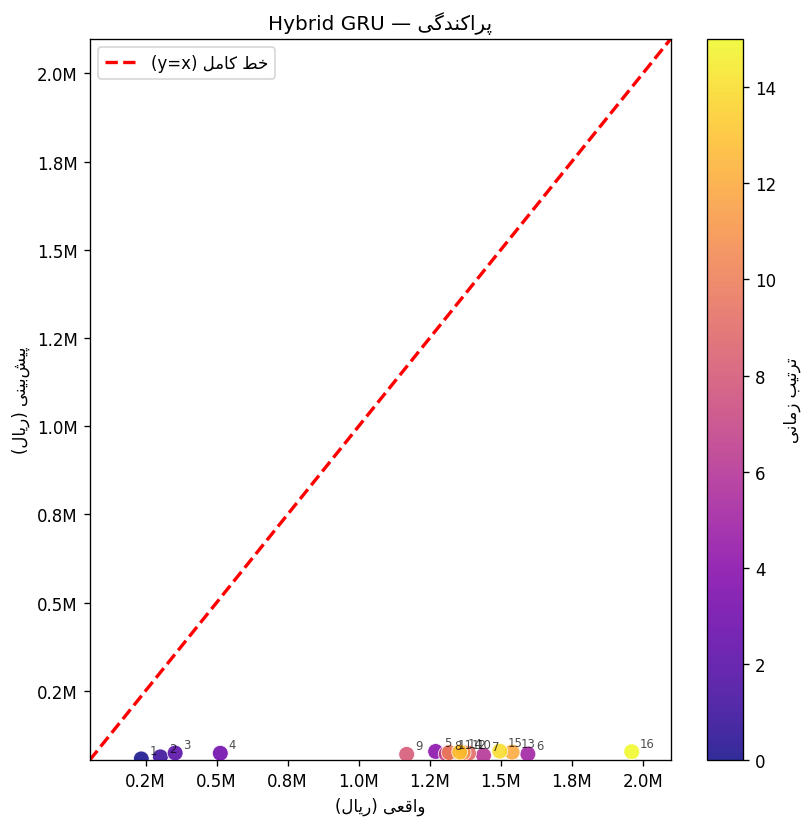

✓ نمودار ۸ ذخیره شد


In [58]:
# نمودار ۸ — Scatter: واقعی vs پیش‌بینی
fig, ax = plt.subplots(figsize=(7, 7))
sc = ax.scatter(y_true_price, y_pred_price,
                c=range(N_TEST), cmap="plasma", s=90, alpha=0.85,
                edgecolors="white", lw=0.5, zorder=3)
lim_lo = min(y_true_price.min(), y_pred_price.min()) * 0.93
lim_hi = max(y_true_price.max(), y_pred_price.max()) * 1.07
ax.plot([lim_lo,lim_hi],[lim_lo,lim_hi],"r--",lw=2,label=fp("خط کامل (y=x)"))
for i,(xt,xp) in enumerate(zip(y_true_price,y_pred_price)):
    ax.annotate(str(i+1),(xt,xp),textcoords="offset points",
                xytext=(5,3),fontsize=7,alpha=0.7)
ax.set_xlim(lim_lo,lim_hi); ax.set_ylim(lim_lo,lim_hi)
ax.set_xlabel(fp("واقعی (ریال)")); ax.set_ylabel(fp("پیش‌بینی (ریال)"))
ax.set_title(fp("پراکندگی — Hybrid GRU"))
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x/1e6:.1f}M"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x/1e6:.1f}M"))
ax.legend(); plt.colorbar(sc, ax=ax, label=fp("ترتیب زمانی"))
plt.tight_layout()
plt.savefig("../results/figures/04_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ نمودار ۸ ذخیره شد")

## ۸. عملکرد به تفکیک رژیم اقتصادی

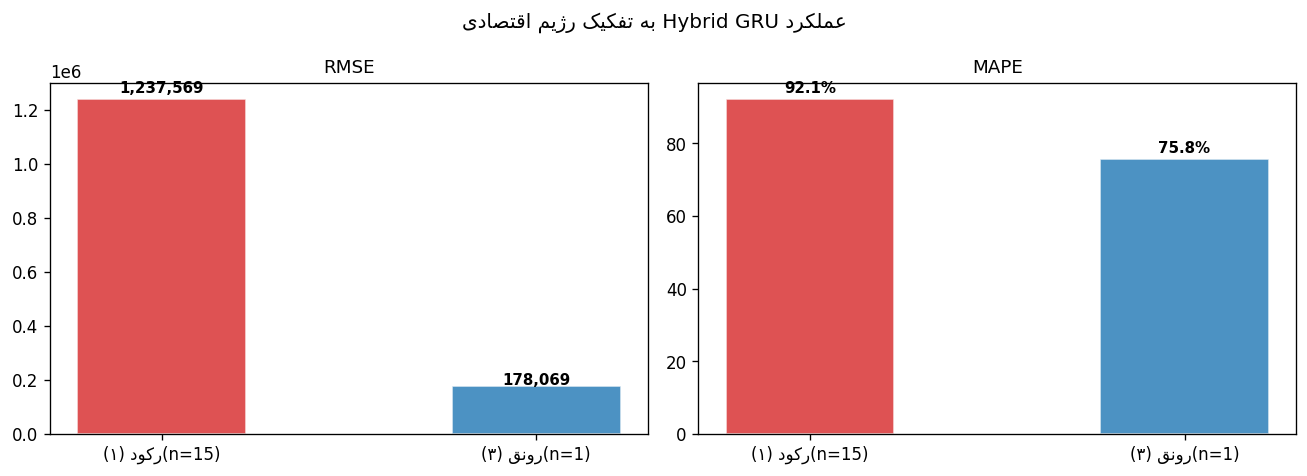

✓ نمودار ۹ ذخیره شد


In [59]:
# نمودار ۹ — عملکرد به تفکیک چرخه
cycle_vals = test_c["cycle"].values
cyc_col  = {1:"#d62728",2:"#2ca02c",3:"#1f77b4"}
cyc_name = {1:fp("رکود (۱)"),2:fp("عادی (۲)"),3:fp("رونق (۳)")}
cyc_m = {}
for c in sorted(set(cycle_vals.astype(int))):
    mask = cycle_vals == c
    if not mask.any(): continue
    yt,yp = y_true_price[mask], y_pred_price[mask]
    cyc_m[c] = {"RMSE":np.sqrt(mean_squared_error(yt,yp)),
                "MAPE":np.mean(np.abs((yt-yp)/yt))*100,"n":mask.sum()}

keys = sorted(cyc_m.keys())
fig, axes = plt.subplots(1,2,figsize=(11,4))
for ax_i,metric in enumerate(["RMSE","MAPE"]):
    vals   = [cyc_m[k][metric] for k in keys]
    labels = [f"{cyc_name.get(k,k)}(n={cyc_m[k]['n']})" for k in keys]
    bars   = axes[ax_i].bar(labels, vals, color=[cyc_col.get(k,"gray") for k in keys],
                             alpha=0.8, edgecolor="white", width=0.45)
    for bar,v in zip(bars,vals):
        axes[ax_i].text(bar.get_x()+bar.get_width()/2,bar.get_height()*1.02,
                         f"{v:,.0f}" if metric=="RMSE" else f"{v:.1f}%",
                         ha="center",fontsize=9,fontweight="bold")
    axes[ax_i].set_title(f"{metric}",fontsize=11)
plt.suptitle(fp("عملکرد Hybrid GRU به تفکیک رژیم اقتصادی"),fontsize=12)
plt.tight_layout()
plt.savefig("../results/figures/04_performance_by_cycle.png",dpi=150,bbox_inches="tight")
plt.show()
print("✓ نمودار ۹ ذخیره شد")

## ۹. مقایسه کامل ۴ مدل فاز ۲

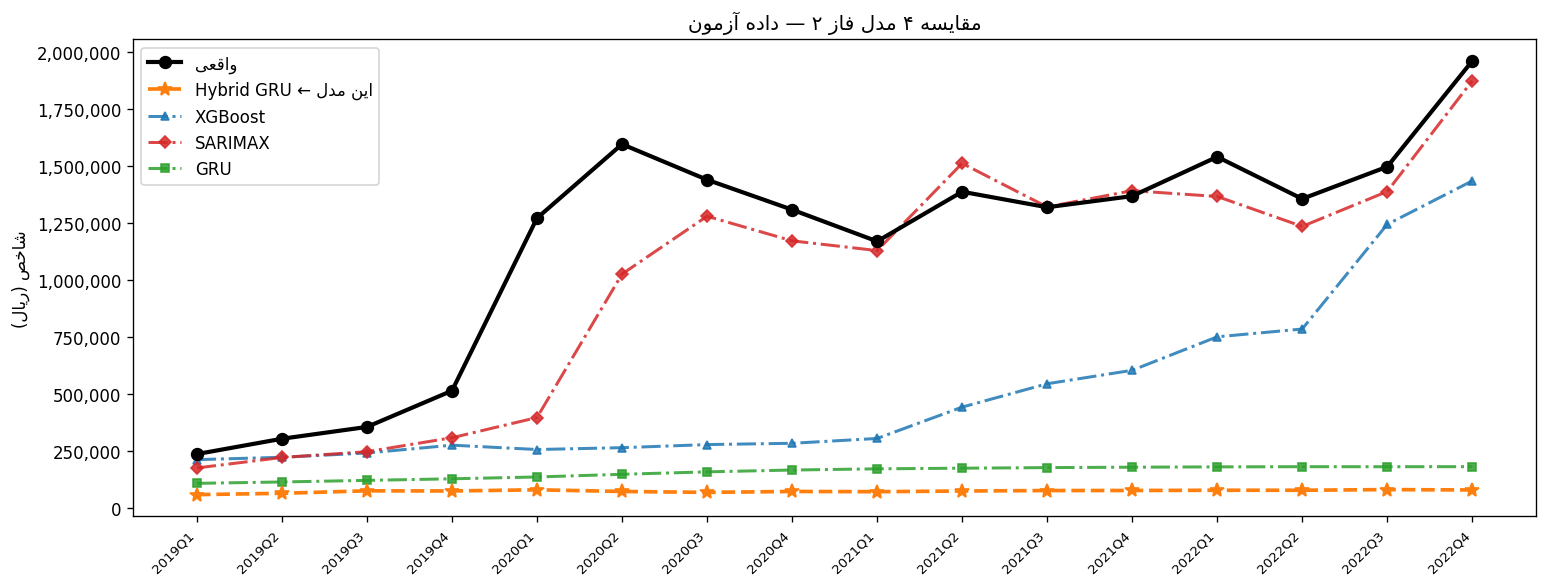

✓ نمودار ۱۰ ذخیره شد


In [60]:
# نمودار ۱۰ — مقایسه همه مدل‌ها روی یک نمودار
fig, ax = plt.subplots(figsize=(13, 5))

colors_m = {"واقعی":"black","XGBoost":"#1f77b4",
            "SARIMAX":"#d62728","GRU":"#2ca02c","Hybrid GRU":"#ff7f0e"}
markers  = {"واقعی":"o","XGBoost":"^","SARIMAX":"D","GRU":"s","Hybrid GRU":"*"}

ax.plot(x_t, y_true_price, color="black", marker="o", ms=7, lw=2.5,
        label=fp("واقعی"), zorder=6)
ax.plot(x_t, y_pred_price, color="#ff7f0e", marker="*", ms=9, lw=2.2,
        linestyle="--", label=fp("Hybrid GRU ← این مدل"), zorder=5)

for fname, lname, col, mk in [
    ("../results/metrics/01_xgboost_predictions.csv",
     "XGBoost","#1f77b4","^"),
    ("../results/metrics/02_sarimax_predictions.csv",
     "SARIMAX","#d62728","D"),
    ("../results/metrics/03_gru_predictions.csv",
     "GRU","#2ca02c","s")
]:
    if os.path.exists(fname):
        df_r = pd.read_csv(fname)
        col_p = "پیش‌بینی" if "پیش‌بینی" in df_r.columns else "predicted"
        ax.plot(x_t, df_r[col_p].values[:N_TEST],
                color=col, marker=mk, ms=5, lw=1.8,
                linestyle="-.", label=fp(lname), zorder=4, alpha=0.85)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x:,.0f}"))
ax.set_ylabel(fp("شاخص (ریال)")); ax.set_title(fp("مقایسه ۴ مدل فاز ۲ — داده آزمون"),fontsize=12)
ax.set_xticks(x_t)
ax.set_xticklabels(test_c.index.astype(str),rotation=45,ha="right",fontsize=8)
ax.legend(); plt.tight_layout()
plt.savefig("../results/figures/04_all_models_line.png",dpi=150,bbox_inches="tight")
plt.show()
print("✓ نمودار ۱۰ ذخیره شد")

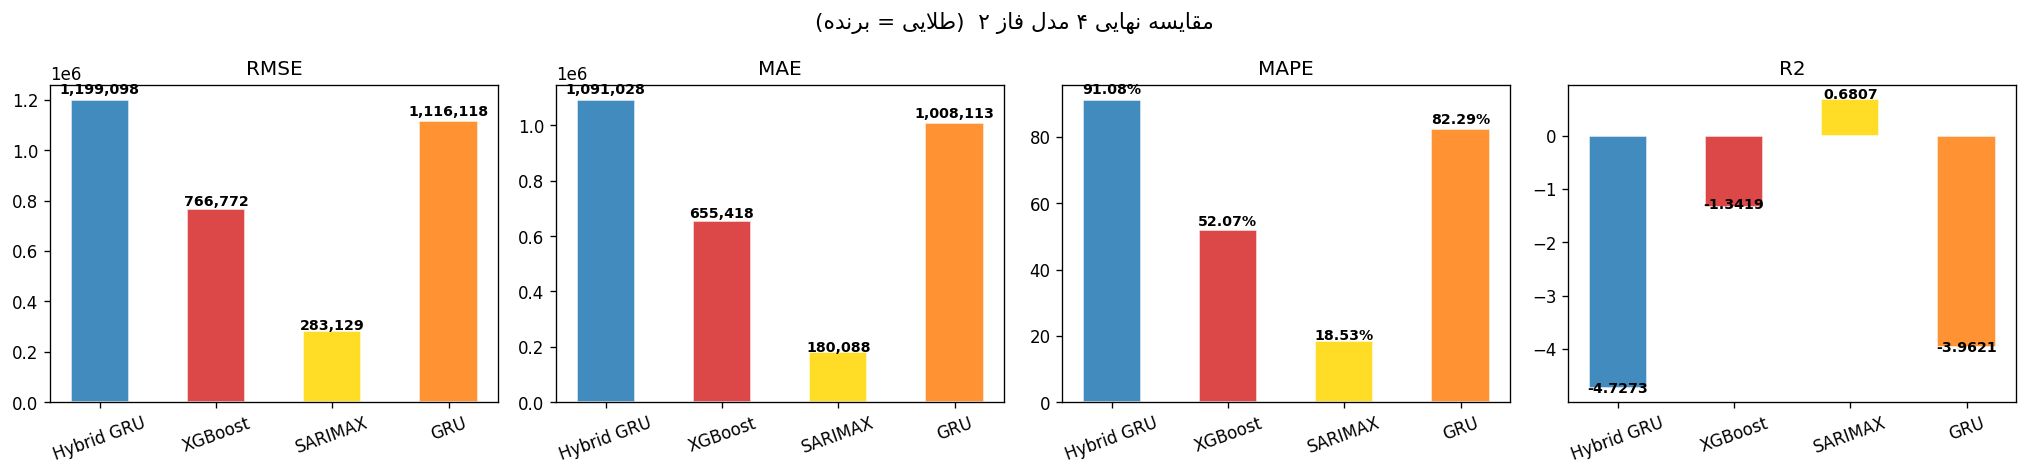

✓ نمودار ۱۱ ذخیره شد
RMSE=1,199,098  MAE=1,091,028  MAPE=91.08%  R²=-4.7273


In [61]:
# نمودار ۱۱ — جدول مقایسه معیارها (radar + bar)
RMSE = np.sqrt(mean_squared_error(y_true_price,y_pred_price))
MAE  = mean_absolute_error(y_true_price,y_pred_price)
MAPE = np.mean(np.abs((y_true_price-y_pred_price)/y_true_price))*100
R2   = r2_score(y_true_price,y_pred_price)
metrics = {"model":"Hybrid GRU","RMSE":RMSE,"MAE":MAE,"MAPE":MAPE,"R2":R2}

all_m = {"Hybrid GRU":{"RMSE":RMSE,"MAE":MAE,"MAPE":MAPE,"R2":R2}}
for fname,mname in [("01_xgboost_metrics.csv","XGBoost"),
                     ("02_sarimax_metrics.csv","SARIMAX"),
                     ("03_gru_metrics.csv","GRU")]:
    p = f"../results/metrics/{fname}"
    if os.path.exists(p):
        row = pd.read_csv(p).iloc[0]
        all_m[mname] = {"RMSE":row["RMSE"],"MAE":row["MAE"],
                         "MAPE":row["MAPE"],"R2":row["R2"]}

names   = list(all_m.keys())
pal     = ["#1f77b4","#d62728","#2ca02c","#ff7f0e"][:len(names)]
fig, axes = plt.subplots(1, 4, figsize=(17, 4))
for ax_i,metric in enumerate(["RMSE","MAE","MAPE","R2"]):
    vals   = [all_m[n][metric] for n in names]
    winner = int(np.argmin(vals)) if metric!="R2" else int(np.argmax(vals))
    bar_c  = ["#ffd700" if i==winner else c for i,c in enumerate(pal[:len(names)])]
    bars   = axes[ax_i].bar(names, vals, color=bar_c, alpha=0.85,
                             edgecolor="white", width=0.5)
    for bar,v in zip(bars,vals):
        fmt = f"{v:,.0f}" if metric in ["RMSE","MAE"] else               (f"{v:.2f}%" if metric=="MAPE" else f"{v:.4f}")
        axes[ax_i].text(bar.get_x()+bar.get_width()/2,
                         bar.get_height()*1.02,fmt,
                         ha="center",fontsize=8.5,fontweight="bold")
    axes[ax_i].set_title(metric,fontsize=12)
    axes[ax_i].tick_params(axis="x",rotation=20)
plt.suptitle(fp("مقایسه نهایی ۴ مدل فاز ۲  (طلایی = برنده)"),fontsize=13)
plt.tight_layout()
plt.savefig("../results/figures/04_final_metrics_comparison.png",dpi=150,bbox_inches="tight")
plt.show()
print("✓ نمودار ۱۱ ذخیره شد")
print(f"RMSE={RMSE:,.0f}  MAE={MAE:,.0f}  MAPE={MAPE:.2f}%  R²={R2:.4f}")

## ۱۰. جدول خلاصه نهایی پروژه

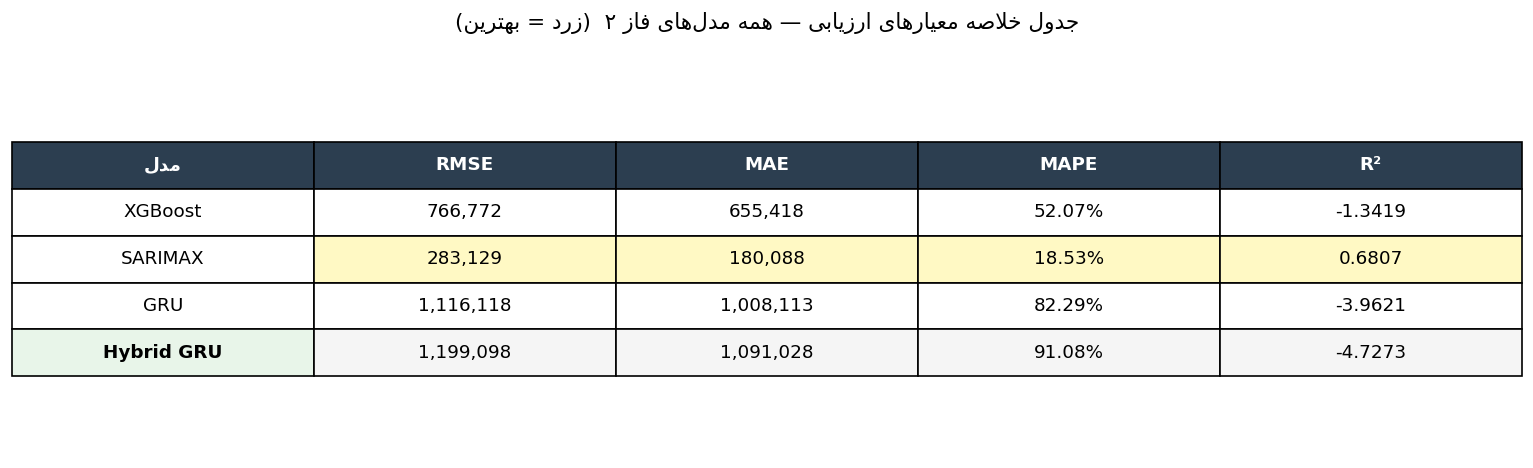

✓ نمودار ۱۲ ذخیره شد


In [62]:
# نمودار ۱۲ — جدول رنگی خلاصه همه مدل‌ها
fig, ax = plt.subplots(figsize=(13, 4))
ax.axis("off")

rows  = []
order = ["XGBoost","SARIMAX","GRU","Hybrid GRU"]
for mname in order:
    if mname in all_m:
        m = all_m[mname]
        rows.append([mname,
                     f"{m['RMSE']:,.0f}",
                     f"{m['MAE']:,.0f}",
                     f"{m['MAPE']:.2f}%",
                     f"{m['R2']:.4f}"])

col_lbl = [fp("مدل"),fp("RMSE"),fp("MAE"),fp("MAPE"),fp("R²")]
tbl = ax.table(cellText=rows, colLabels=col_lbl,
               loc="center", cellLoc="center")
tbl.auto_set_font_size(False); tbl.set_fontsize(11); tbl.scale(1.3, 2.2)

# رنگ‌بندی
metrics_cols = {"RMSE":1,"MAE":2,"MAPE":3,"R2":4}
for metric,col_idx in metrics_cols.items():
    col_vals = [float(rows[i][col_idx].replace(",","").replace("%",""))
                for i in range(len(rows))]
    best_row = (np.argmin(col_vals)+1 if metric!="R2" else np.argmax(col_vals)+1)
    for r in range(1, len(rows)+1):
        cell = tbl[r, col_idx]
        cell.set_facecolor("#fff9c4" if r==best_row else
                           ("#f5f5f5" if r%2==0 else "white"))

for (r,c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor("#2c3e50")
        cell.set_text_props(color="white", fontweight="bold")
    if c == 0 and r > 0 and rows[r-1][0] == "Hybrid GRU":
        cell.set_facecolor("#e8f5e9")
        cell.set_text_props(fontweight="bold")

ax.set_title(fp("جدول خلاصه معیارهای ارزیابی — همه مدل‌های فاز ۲  (زرد = بهترین)"),
             fontsize=13, pad=20)
plt.tight_layout()
plt.savefig("../results/figures/04_summary_table.png",dpi=150,bbox_inches="tight")
plt.show()
print("✓ نمودار ۱۲ ذخیره شد")

## ۱۱. ذخیره مدل‌ها و نتایج

In [63]:
os.makedirs("../models",          exist_ok=True)
os.makedirs("../results/metrics", exist_ok=True)

# ذخیره همه اجزای pipeline
torch.save({
    "model_state":  model.state_dict(),
    "input_size":   INPUT_SIZE,
    "hidden_size":  32,
    "window":       WINDOW,
    "k_selected":   K_SELECTED,
    "top_k_idx":    top_k_idx,
    "best_epoch":   best_epoch,
    "history":      history
}, "../models/04_hybrid_gru.pt")

joblib.dump({
    "std_scaler": std_scaler,
    "pca":        pca_n99,
    "rf_model":   rf_model,
    "price_sc":   price_sc
}, "../models/04_hybrid_preprocessors.pkl")

pd.DataFrame([metrics]).to_csv(
    "../results/metrics/04_hybrid_metrics.csv", index=False)
result_df.to_csv(
    "../results/metrics/04_hybrid_predictions.csv", index=False)

print("✓ GRU model  : ../models/04_hybrid_gru.pt")
print("✓ Preprocessors: ../models/04_hybrid_preprocessors.pkl")
print("✓ Metrics    : ../results/metrics/04_hybrid_metrics.csv")
figs = sorted([f for f in os.listdir("../results/figures") if f.startswith("04_")])
print(f"نمودارهای ذخیره‌شده ({len(figs)} عدد):")
for f in figs: print(f"  📊 {f}")

✓ GRU model  : ../models/04_hybrid_gru.pt
✓ Preprocessors: ../models/04_hybrid_preprocessors.pkl
✓ Metrics    : ../results/metrics/04_hybrid_metrics.csv
نمودارهای ذخیره‌شده (12 عدد):
  📊 04_actual_vs_predicted.png
  📊 04_all_models_line.png
  📊 04_final_metrics_comparison.png
  📊 04_hybrid_architecture.png
  📊 04_pca_biplot_loadings.png
  📊 04_pca_scree.png
  📊 04_performance_by_cycle.png
  📊 04_residuals.png
  📊 04_rf_importance.png
  📊 04_scatter.png
  📊 04_summary_table.png
  📊 04_training_curve.png


## ✅ خلاصه نتایج مدل Hybrid GRU

| # | نمودار | نوع | بخش |
|---|--------|-----|-----|
| ۱ | `04_hybrid_architecture` | Diagram | معماری |
| ۲ | `04_pca_scree` | Scree + Cumulative Line | لایه PCA |
| ۳ | `04_pca_biplot_loadings` | Scatter + Heatmap | لایه PCA |
| ۴ | `04_rf_importance` | H-Bar + Pie | لایه RF |
| ۵ | `04_training_curve` | Line + Log-LR | آموزش GRU |
| ۶ | `04_actual_vs_predicted` | Line (log + price) | پیش‌بینی |
| ۷ | `04_residuals` | Bar + Hist/KDE + Q-Q | خطا |
| ۸ | `04_scatter` | Scatter + colorbar | پیش‌بینی |
| ۹ | `04_performance_by_cycle` | Grouped Bar | چرخه |
| ۱۰ | `04_all_models_line` | Multi-line | مقایسه |
| ۱۱ | `04_final_metrics_comparison` | Grouped Bar | مقایسه |
| ۱۲ | `04_summary_table` | جدول رنگی | خلاصه |

**🎯 پروژه کامل شد — همه ۴ مدل فاز ۲ پیاده‌سازی شدند.**